# London Temperature Forecasting Using ARIMA and SARIMA

## Project Objective

This project uses historical London weather data from 2016 to 2025 to forecast average temperature. ARIMA and SARIMA models are evaluated using one-shot forecasting and walk-forward validation to determine their forecasting performance.

## Import Libraries

In [1]:
%pip install --upgrade numexpr -q

Note: you may need to restart the kernel to use updated packages.


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datetime import date
import meteostat as ms

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

## Data Collection

In [3]:


start = date(2016, 1, 1)
end = date(2025, 12, 31)

london = ms.Point(51.5074, -0.1278)

stations = ms.stations.nearby(london, limit=4)

ts = ms.daily(stations, start, end)

df = ms.interpolate(ts, london).fetch()

df.head()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
2016-01-01,5.6,0.6,8.4,86,2.3,<NA>,15.8,<NA>,1017.0,<NA>,<NA>
2016-01-02,10.1,8.4,11.4,90,1.8,<NA>,23.6,<NA>,998.0,<NA>,<NA>
2016-01-03,8.1,5.7,10.3,88,6.6,<NA>,17.5,<NA>,991.7,<NA>,<NA>
2016-01-04,8.1,6.6,10.8,86,7.1,<NA>,13.0,<NA>,982.7,<NA>,<NA>
2016-01-05,8.3,5.7,9.9,90,0.5,<NA>,8.6,<NA>,984.7,<NA>,<NA>


## Data Exploration

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3653 entries, 2016-01-01 to 2025-12-31
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    3653 non-null   Float64
 1   tmin    3653 non-null   Float64
 2   tmax    3653 non-null   Float64
 3   rhum    3653 non-null   UInt8  
 4   prcp    3642 non-null   Float64
 5   snwd    73 non-null     UInt16 
 6   wspd    3652 non-null   Float64
 7   wpgt    2640 non-null   Float64
 8   pres    3653 non-null   Float64
 9   tsun    1240 non-null   UInt16 
 10  cldc    1875 non-null   UInt8  
dtypes: Float64(7), UInt16(2), UInt8(2)
memory usage: 289.0 KB


In [5]:
df.shape

(3653, 11)

In [6]:
df.isnull().sum()/len(df) * 100

temp     0.000000
tmin     0.000000
tmax     0.000000
rhum     0.000000
prcp     0.301122
snwd    98.001642
wspd     0.027375
wpgt    27.730632
pres     0.000000
tsun    66.055297
cldc    48.672324
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
count,3653.0,3653.0,3653.0,3653.0,3642.0,73.0,3652.0,2640.0,3653.0,1240.0,1875.0
mean,11.407857,8.016397,14.867561,78.221736,1.794124,0.287671,14.391676,32.976439,1015.342787,213.11129,4.159467
std,5.585881,5.015505,6.490264,10.3525,3.573047,0.513145,5.732297,10.612913,10.735441,181.919841,2.664975
min,-3.7,-5.9,-1.9,39.0,0.0,0.0,2.8,11.1,967.9,0.0,0.0
25%,7.2,4.3,10.0,71.0,0.0,0.0,10.1,25.9,1008.7,65.0,2.0
50%,11.2,8.0,14.3,79.0,0.2,0.0,13.5,31.5,1016.4,173.0,5.0
75%,15.9,11.9,19.7,86.0,1.9,1.0,17.5,38.9,1022.6,321.25,6.0
max,27.8,20.5,35.5,100.0,36.6,2.0,45.9,98.2,1047.3,879.0,8.0


## Exploratory Data Analysis

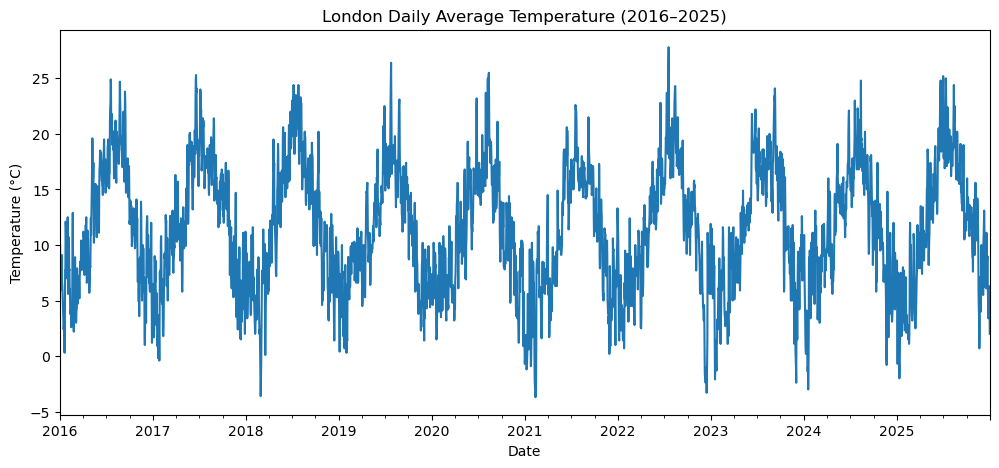

In [9]:
df["temp"].plot(figsize=(12, 5))

plt.title("London Daily Average Temperature (2016–2025)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show();

### Observation

The temperature series shows a clear recurring annual pattern, with higher temperatures during the warmer months and lower temperatures during the colder months. This indicates strong seasonality in London's daily average temperature and suggests that a seasonal forecasting model may be appropriate.

In [10]:
monthly_temp = df["temp"].groupby(df.index.month).mean()

monthly_temp

time
1      4.810323
2      6.187986
3      7.577097
4      9.641667
5     13.310645
6     16.769667
7     18.467419
8     17.982258
9     15.442333
10    12.056452
11        7.911
12     6.416129
Name: temp, dtype: Float64

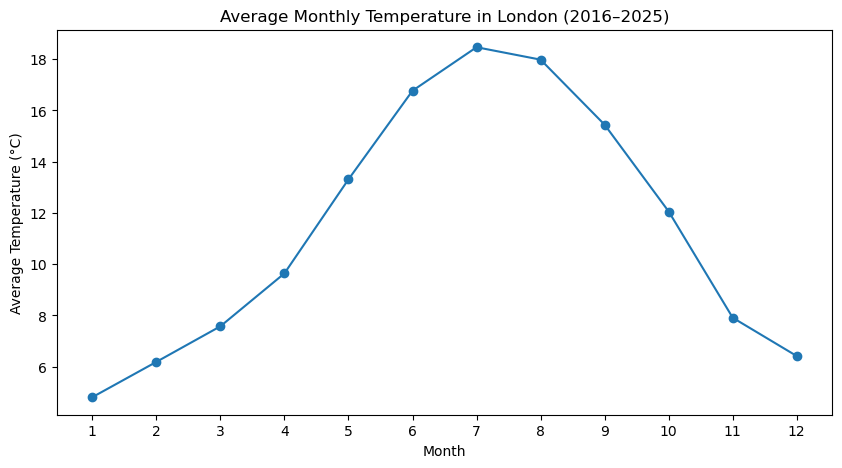

In [11]:
monthly_temp.plot(figsize=(10, 5), marker="o")

plt.title("Average Monthly Temperature in London (2016–2025)")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.xticks(range(1, 13))
plt.show();

### Observation

London's average temperature shows a clear seasonal pattern. Temperatures rise from January, peak in July at approximately 18.5°C, and then decline toward December. This confirms the presence of strong annual seasonality in the temperature data.

In [12]:
adf_test = adfuller(df["temp"])

print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

ADF Statistic: -3.707568890159211
p-value: 0.00400794178763962


### Observation

The ADF test produced a p-value of approximately 0.004, which is below 0.05. Therefore, we reject the null hypothesis of a unit root, providing evidence that the temperature series is stationary. This suggests that non-seasonal differencing may not be required.

## Autocorrelation Analysis

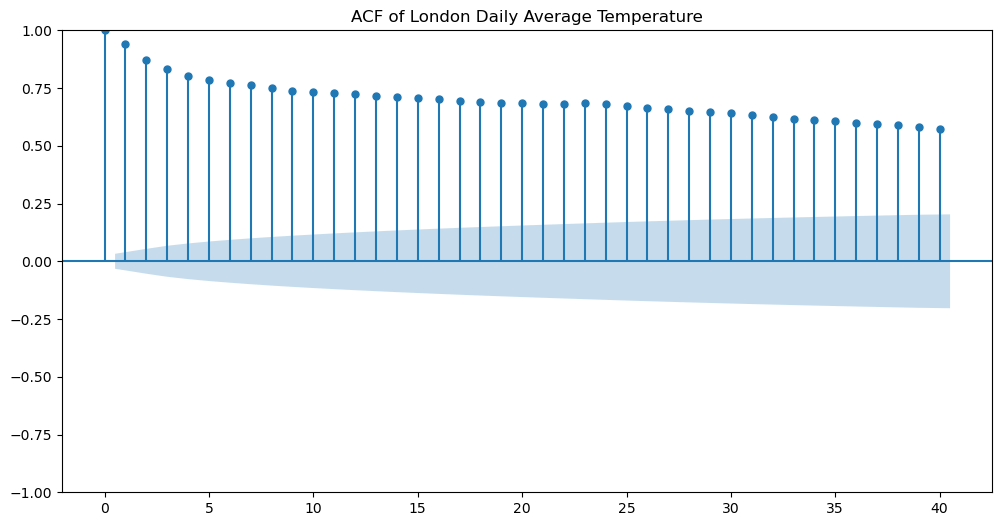

In [13]:
fig,ax = plt.subplots(figsize=(12,6))
plot_acf(df["temp"], lags=40,ax=ax)
plt.title("ACF of London Daily Average Temperature")
plt.show();

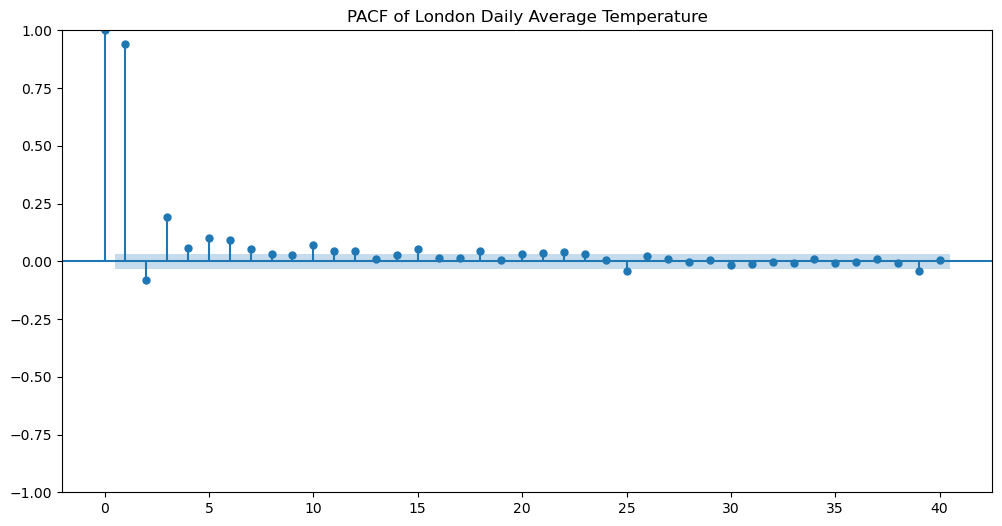

In [14]:
fig,ax = plt.subplots(figsize=(12,6))
plot_pacf(df["temp"], lags=40,ax=ax)
plt.title("PACF of London Daily Average Temperature")
plt.show();

### Observation

The ACF shows strong and slowly declining autocorrelation, while the PACF has a dominant spike at lag 1. This suggests that recent temperatures, particularly the previous day's temperature, are important for forecasting.


##  ARIMA Modeling

### Train-Test Split

In [15]:
df = df.asfreq("D")

In [16]:
y = df["temp"]

y_train = y.iloc[:-365]
y_test = y.iloc[-365:]

print("Training observations:", len(y_train))
print("Testing observations:", len(y_test))
print("Training period:", y_train.index.min(), "to", y_train.index.max())
print("Testing period:", y_test.index.min(), "to", y_test.index.max())

Training observations: 3288
Testing observations: 365
Training period: 2016-01-01 00:00:00 to 2024-12-31 00:00:00
Testing period: 2025-01-01 00:00:00 to 2025-12-31 00:00:00


### Observation

The data was split chronologically, using observations from 2016–2024 for training and 2025 for testing. This preserves the time order and prevents future information from leaking into the training data.

In [17]:
y_mean = y_train.mean()

y_pred_baseline = [y_mean] * len(y_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

print("Mean Temperature:", y_mean)
print("Baseline MAE:", mae_baseline)

Mean Temperature: 11.366879562043797
Baseline MAE: 5.016700079992001


### Observation

The mean baseline model produced an MAE of approximately 5.02°C. Therefore, the forecasting models should achieve an MAE below 5.02°C to outperform the baseline.

### ARIMA Hyperparameter Tuning

In [39]:


p_params = range(0, 4)
q_params = range(0, 4)
results = []

for p in p_params:
    for q in q_params:

        order = (p, 0, q)

        start_time = time.time()

        model = ARIMA(y_train, order=order).fit()

        elapsed_time = round(time.time() - start_time, 2)

        y_pred = model.predict()

        mae = mean_absolute_error(y_train, y_pred)

        results.append({
            "p": p,
            "q": q,
            "ARIMA Order": order,
            "MAE": mae,
            "Training Time (sec)": elapsed_time
        })

tuning_results = pd.DataFrame(results)

tuning_results

,p,q,ARIMA Order,MAE,Training Time (sec)
0,0,0,"(0, 0, 0)",4.603705,0.61
1,0,1,"(0, 0, 1)",2.755235,0.53
2,0,2,"(0, 0, 2)",2.159632,0.87
3,0,3,"(0, 0, 3)",1.908524,1.08
4,1,0,"(1, 0, 0)",1.481432,0.25
5,1,1,"(1, 0, 1)",1.474600,0.89
6,1,2,"(1, 0, 2)",1.448079,1.44
7,1,3,"(1, 0, 3)",1.436155,1.99
8,2,0,"(2, 0, 0)",1.476919,0.95
9,2,1,"(2, 0, 1)",1.465759,1.40


In [19]:
results.append({
    "p": p,
    "q": q,
    "ARIMA Order": order,
    "MAE": mae,
    "Training Time (sec)": elapsed_time
})

In [20]:
mae_df = tuning_results.pivot(
    index="q",
    columns="p",
    values="MAE"
)

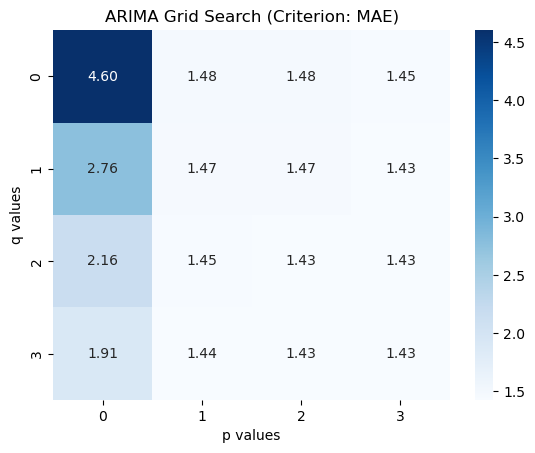

In [21]:
sns.heatmap(
    mae_df,
    cmap="Blues",
    annot=True,
    fmt=".2f"
)

plt.xlabel("p values")
plt.ylabel("q values")
plt.title("ARIMA Grid Search (Criterion: MAE)")
plt.show();

### Observation

ARIMA(2,0,2) produced the lowest training MAE of approximately 1.43°C and was therefore selected as the preferred ARIMA model.


In [22]:
arima_model = ARIMA(y_train, order=(2, 0, 2))

arima_result = arima_model.fit()

arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   temp   No. Observations:                 3288
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -6671.294
Date:                Thu, 27 Aug 2026   AIC                          13354.588
Time:                        17:32:23   BIC                          13391.176
Sample:                    01-01-2016   HQIC                         13367.687
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.0797      1.297      8.545      0.000       8.538      13.621
ar.L1          1.5654      0.031     50.555      0.000       1.505       1.626
ar.L2         -0.5691      0.030    -18.737      0.000      -0.629      -0.510
ma.L1         -0.5842      0.031    -18.708      0.000      -0.645      -0.523
ma.L2         -0.2654      0.019    -14.306      0.000      -0.302      -0.229
sigma2         3.3849      0.074     46.023      0.000       3.241       3.529
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                81.08
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                             0.07
Prob(H) (two-sided):                  0.88   Kurtosis:                         3.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [23]:
y_pred_arima = arima_result.forecast(steps=len(y_test))

mae_arima = mean_absolute_error(y_test, y_pred_arima)

print("Baseline MAE:", mae_baseline)
print("ARIMA MAE:", mae_arima)

Baseline MAE: 5.016700079992001
ARIMA MAE: 4.7796695853664


### Observation

The ARIMA(2,0,2) model achieved a test MAE of approximately **4.78°C**, outperforming the baseline MAE of **5.02°C**. However, the improvement is relatively small, suggesting that the ARIMA model may not fully capture the strong seasonal pattern in London temperatures.


### ARIMA Walk-Forward Validation

In [24]:
# Use the last 60 days of 2025 for walk-forward validation
y_test_wfv = y_test.iloc[-60:]

# History includes everything before those 60 days
history = y.iloc[:-60].copy()

# Empty Series to store predictions
y_pred_wfv = pd.Series(dtype=float)

# Walk-forward validation
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for i in range(len(y_test_wfv)):
        model = ARIMA(history, order=(2, 0, 2)).fit()

        next_pred = model.forecast(steps=1)

        y_pred_wfv = pd.concat([y_pred_wfv, next_pred])

        history = pd.concat([history, y_test_wfv.iloc[[i]]])

# Calculate MAE
mae_wfv = mean_absolute_error(y_test_wfv, y_pred_wfv)

print("ARIMA Walk-Forward MAE:", mae_wfv)

ARIMA Walk-Forward MAE: 1.5632078329494241


### Observation

The ARIMA(2,0,2) walk-forward validation achieved an MAE of approximately **1.56°C**, substantially outperforming both the baseline model and the one-shot ARIMA forecast. This shows that updating the model with newly observed temperatures significantly improves short-term forecasting accuracy.


In [25]:
y_monthly = df["temp"].resample("MS").mean()

y_monthly.head()

time
2016-01-01      6.73871
2016-02-01     6.262069
2016-03-01     6.874194
2016-04-01     8.983333
2016-05-01    14.029032
Freq: MS, Name: temp, dtype: Float64

In [26]:
y_train_monthly = y_monthly.loc[:"2024-12-01"]
y_test_monthly = y_monthly.loc["2025-01-01":]

print("Training observations:", len(y_train_monthly))
print("Testing observations:", len(y_test_monthly))

print("Training period:", y_train_monthly.index.min(), "to", y_train_monthly.index.max())
print("Testing period:", y_test_monthly.index.min(), "to", y_test_monthly.index.max())

Training observations: 108
Testing observations: 12
Training period: 2016-01-01 00:00:00 to 2024-12-01 00:00:00
Testing period: 2025-01-01 00:00:00 to 2025-12-01 00:00:00


## SARIMA Model

## SARIMA Hyperparameter Tuning

In [27]:
# SARIMA parameter ranges
p_params = range(0, 3)
q_params = range(0, 3)

P_params = range(0, 2)
Q_params = range(0, 2)

sarima_results = []

for p in p_params:
    for q in q_params:
        for P in P_params:
            for Q in Q_params:

                order = (p, 0, q)
                seasonal_order = (P, 1, Q, 12)

                start_time = time.time()

                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")

                        model = SARIMAX(
                            y_train_monthly,
                            order=order,
                            seasonal_order=seasonal_order
                        ).fit(disp=False)

                    elapsed_time = round(time.time() - start_time, 2)

                    y_pred = model.predict()

                    mae = mean_absolute_error(
                        y_train_monthly,
                        y_pred
                    )

                    sarima_results.append({
                        "p": p,
                        "q": q,
                        "P": P,
                        "Q": Q,
                        "Order": order,
                        "Seasonal Order": seasonal_order,
                        "MAE": mae,
                        "Training Time (sec)": elapsed_time,
                        "Converged": model.mle_retvals["converged"]
                    })

                except Exception:
                    pass

sarima_tuning_results = pd.DataFrame(sarima_results)

sarima_tuning_results

,p,q,P,Q,Order,Seasonal Order,MAE,Training Time (sec),Converged
0,0,0,0,0,"(0, 0, 0)","(0, 1, 0, 12)",2.849877,0.07,True
1,0,0,0,1,"(0, 0, 0)","(0, 1, 1, 12)",2.474414,0.23,True
2,0,0,1,0,"(0, 0, 0)","(1, 1, 0, 12)",2.486263,0.05,True
3,0,0,1,1,"(0, 0, 0)","(1, 1, 1, 12)",2.442794,0.12,True
4,0,1,0,0,"(0, 0, 1)","(0, 1, 0, 12)",2.852757,0.03,True
5,0,1,0,1,"(0, 0, 1)","(0, 1, 1, 12)",2.416933,0.32,True
6,0,1,1,0,"(0, 0, 1)","(1, 1, 0, 12)",2.394785,0.08,True
7,0,1,1,1,"(0, 0, 1)","(1, 1, 1, 12)",2.351728,0.28,True
8,0,2,0,0,"(0, 0, 2)","(0, 1, 0, 12)",2.741030,0.04,True
9,0,2,0,1,"(0, 0, 2)","(0, 1, 1, 12)",2.388356,0.45,True




### Observation

SARIMA(2,0,2)(1,1,1,12) achieved the lowest training MAE of approximately **2.28°C** among the tested models and successfully converged. It was therefore selected as the preferred SARIMA model.


In [28]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    sarima_model = SARIMAX(
        y_train_monthly,
        order=(2, 0, 2),
        seasonal_order=(1, 1, 1, 12)
    )

    sarima_result = sarima_model.fit(disp=False)

sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                 temp   No. Observations:                  108
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 12)   Log Likelihood                -162.564
Date:                              Thu, 27 Aug 2026   AIC                            339.127
Time:                                      17:36:59   BIC                            357.078
Sample:                                  01-01-2016   HQIC                           346.383
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4832      0.218      2.219      0.027       0.056       0.910
ar.L2          0.4795      0.200      2.396      0.017       0.087       0.872
ma.L1         -0.0464      0.183     -0.254      0.800      -0.405       0.312
ma.L2         -0.7084      0.139     -5.101      0.000      -0.981      -0.436
ar.S.L12      -0.4018      0.127     -3.157      0.002      -0.651      -0.152
ma.S.L12      -0.8175      0.213     -3.844      0.000      -1.234      -0.401
sigma2         1.3889      0.273      5.095      0.000       0.855       1.923
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 0.52
Prob(Q):                              0.77   Prob(JB):                         0.77
Heteroskedasticity (H):               0.91   Skew:                            -0.09
Prob(H) (two-sided):                  0.79   Kurtosis:                         2.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
y_pred_sarima = sarima_result.forecast(steps=len(y_test_monthly))

mae_sarima = mean_absolute_error(
    y_test_monthly,
    y_pred_sarima
)

print("SARIMA MAE:", mae_sarima)

SARIMA MAE: 1.296694998644615


### Observation

The SARIMA(2,0,2)(1,1,1,12) model achieved a one-shot forecast MAE of approximately **1.30°C**, showing strong forecasting performance and effectively capturing the seasonal pattern in London temperatures. Additionally, the **Ljung-Box Prob(Q) of 0.77** suggests no significant autocorrelation remains in the residuals, indicating that the model captures the temporal structure of the data well.


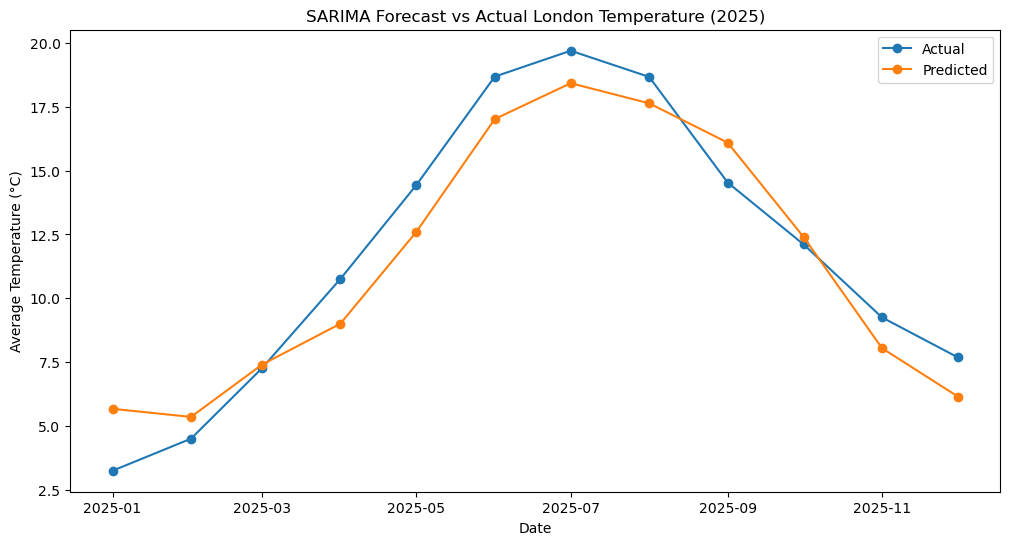

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_monthly.index,
    y_test_monthly,
    marker="o",
    label="Actual"
)

plt.plot(
    y_pred_sarima.index,
    y_pred_sarima,
    marker="o",
    label="Predicted"
)

plt.title("SARIMA Forecast vs Actual London Temperature (2025)")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.show();



### Observation

The SARIMA(2,0,2)(1,1,1,12) forecast successfully captured the seasonal temperature pattern in London, including the rise toward summer and decline toward winter. The predicted temperatures closely followed the actual values, although the model slightly underestimated temperatures during some warmer months.


### SARIMA Walk-Forward Validation

In [31]:
y_pred_sarima_wfv = pd.Series(dtype=float)

history = y_train_monthly.copy()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for i in range(len(y_test_monthly)):

        model = SARIMAX(
            history,
            order=(2, 0, 2),
            seasonal_order=(1, 1, 1, 12)
        ).fit(disp=False)

        next_pred = model.forecast(steps=1)

        y_pred_sarima_wfv = pd.concat(
            [y_pred_sarima_wfv, next_pred]
        )

        history = pd.concat(
            [history, y_test_monthly.iloc[[i]]]
        )

mae_sarima_wfv = mean_absolute_error(
    y_test_monthly,
    y_pred_sarima_wfv
)

print("SARIMA Walk-Forward MAE:", mae_sarima_wfv)

SARIMA Walk-Forward MAE: 1.0799666451473602


In [32]:
mae_sarima_wfv = mean_absolute_error(
    y_test_monthly,
    y_pred_sarima_wfv
)

print("SARIMA One-Shot MAE:", mae_sarima)
print("SARIMA Walk-Forward MAE:", mae_sarima_wfv)

SARIMA One-Shot MAE: 1.296694998644615
SARIMA Walk-Forward MAE: 1.0799666451473602


### Observation

The SARIMA walk-forward validation achieved an MAE of approximately **1.08°C**, improving on the one-shot SARIMA MAE of **1.30°C**. This indicates that updating the model with newly observed temperatures improves forecasting accuracy.


## Monthly ARIMA vs SARIMA Comparison


In [33]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    arima_monthly = ARIMA(
        y_train_monthly,
        order=(2, 0, 2)
    ).fit()

y_pred_arima_monthly = arima_monthly.forecast(
    steps=len(y_test_monthly)
)

mae_arima_monthly = mean_absolute_error(
    y_test_monthly,
    y_pred_arima_monthly
)

print("Monthly ARIMA MAE:", mae_arima_monthly)
print("SARIMA MAE:", mae_sarima)

Monthly ARIMA MAE: 0.989550123235308
SARIMA MAE: 1.296694998644615




### Observation

The monthly ARIMA(2,0,2) model achieved an MAE of approximately **0.99°C**, outperforming the SARIMA model's MAE of approximately **1.30°C**. This suggests that adding explicit seasonal components did not improve the one-shot forecast accuracy for this test period.


In [34]:
y_pred_arima_wfv_monthly = []
history = y_train_monthly.copy()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for i in range(len(y_test_monthly)):
        model = ARIMA(history, order=(2, 0, 2)).fit()
        next_pred = model.forecast(steps=1).iloc[0]
        y_pred_arima_wfv_monthly.append(next_pred)
        history = pd.concat([history, y_test_monthly.iloc[[i]]])

mae_arima_wfv_monthly = mean_absolute_error(
    y_test_monthly, y_pred_arima_wfv_monthly
)

print("Monthly ARIMA Walk-Forward MAE:", mae_arima_wfv_monthly)

Monthly ARIMA Walk-Forward MAE: 1.0033499097132712


In [35]:
mae_arima_wfv_monthly = mean_absolute_error(
    y_test_monthly,
    y_pred_arima_wfv_monthly
)

print("ARIMA Walk-Forward MAE:", mae_arima_wfv_monthly)
print("SARIMA Walk-Forward MAE:", mae_sarima_wfv)

ARIMA Walk-Forward MAE: 1.0033499097132712
SARIMA Walk-Forward MAE: 1.0799666451473602


### Observation

ARIMA achieved a walk-forward MAE of approximately **1.00°C**, outperforming SARIMA's **1.08°C**. This indicates that ARIMA provided slightly better forecasting accuracy than SARIMA when both models were updated with recent monthly temperature observations.


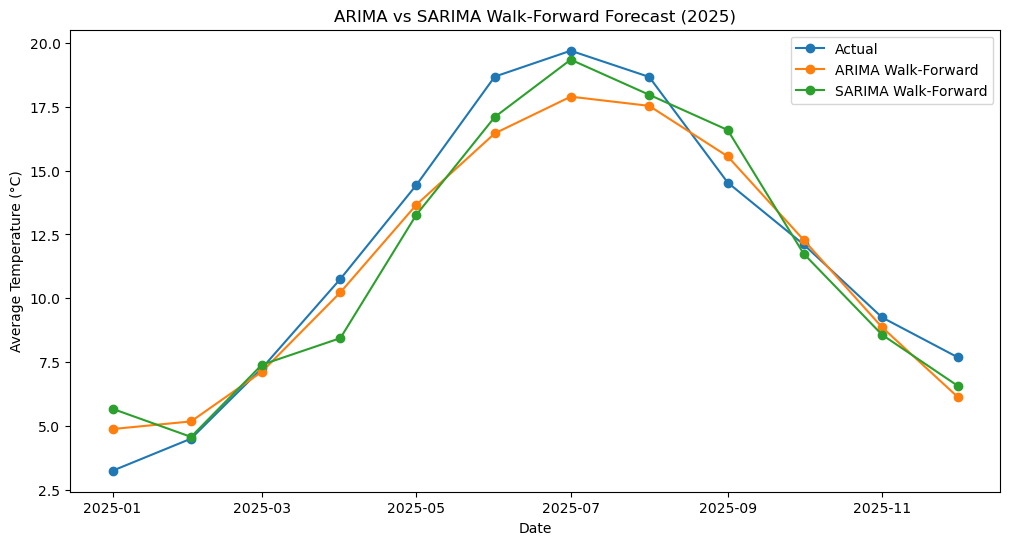

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_monthly.index,
    y_test_monthly,
    marker="o",
    label="Actual"
)

plt.plot(
    y_test_monthly.index,
    y_pred_arima_wfv_monthly,
    marker="o",
    label="ARIMA Walk-Forward"
)

plt.plot(
    y_test_monthly.index,
    y_pred_sarima_wfv,
    marker="o",
    label="SARIMA Walk-Forward"
)

plt.title("ARIMA vs SARIMA Walk-Forward Forecast (2025)")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.show();

### Observation

The ARIMA walk-forward forecast closely followed the actual monthly temperature pattern in 2025, achieving an MAE of approximately **1.00°C**. This demonstrates good short-term forecasting performance when the model is continuously updated with new monthly observations.


In [37]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "One-Shot MAE": [
        mae_arima_monthly,
        mae_sarima
    ],
    "Walk-Forward MAE": [
        mae_arima_wfv_monthly,
        mae_sarima_wfv
    ]
})

comparison

,Model,One-Shot MAE,Walk-Forward MAE
0,ARIMA,0.989550,1.003350
1,SARIMA,1.296695,1.079967


### Final Model Comparison

ARIMA outperformed SARIMA in both forecasting approaches. ARIMA achieved a lower **one-shot MAE of 0.99°C** compared with SARIMA's **1.30°C**, and a lower **walk-forward MAE of 1.00°C** compared with SARIMA's **1.08°C**. Therefore, **ARIMA(2,0,2) was selected as the best-performing model** for forecasting monthly London temperatures.
